In [1]:
import kathprfi_functions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import os
import glob
import pickle
import os
import pdb
from dask import compute
import concurrent.futures
from tqdm.notebook import tqdm

%matplotlib inline

In [2]:
#'/net/stevie/data3/nadeem/KATHPRFI/OUT_ZARR/HH/UBAND/SKA_Baseline',
DATA_PATHS = ['/scratch/kvanqa/RFI_work/2024_UBAND_HH/AUG_HH_U',
              '/scratch/kvanqa/RFI_work/2024_UBAND_HH/SEPT_HH_U',
              '/scratch/kvanqa/RFI_work/2024_UBAND_HH/OCT_HH_U',
              '/scratch/kvanqa/RFI_work/2024_UBAND_HH/NOV_HH_U',
                '/scratch/kvanqa/RFI_work/2024_UBAND_HH/DEC_HH_U',
                '/scratch/kvanqa/RFI_work/2024_UBAND_HH/JUL_HH_U',
                '/scratch/kvanqa/RFI_work/JAN_HH_U/']

def GetZarrList(base_dirs, pattern):
    all_files = []
    for base_dir in base_dirs:
        files = glob.glob(os.path.join(base_dir, "**", pattern), recursive=True)
        all_files.append(files)
    return all_files

AllZarrList = GetZarrList(DATA_PATHS,"*.zarr")
# define the problematic fikle
# problematic_file = "/net/stevie/data3/nadeem/MeerKAT/KATHPRFI/OUT_ZARR/HH/UBAND/SKA_Baseline/UHF_HH_1672117272.zarr"
# AllZarrList = [f for f in AllZarrList0 if f != problematic_file]

print(AllZarrList)
#extraxt the actual files from the path
AllFileNames = [[Files.split('_')[-1] for Files in AllZarrList[i]] for i in range(len(AllZarrList))]


Freq, Time = [], []
origDims = []
baselines = []
elevation_data = []
# Define a helper function to open a Zarr file and extract frequency and time
def open_zarr_data(zarr_path, group="arr"):
    dataset = xr.open_zarr(zarr_path, group=group)
# `orr`, `freq`, and `time` will now be tuples containing the datasets, frequencies, and times respectively
    return list(dataset.coords), dataset["frequency"], dataset["time"], dataset["baseline"], dataset["elevation"]

for j in range(len(AllZarrList)):
    # Use list comprehension to call the helper function
    origDim, freq, time, baseline, elevation = zip(*(open_zarr_data(zarr_path) for zarr_path in AllZarrList[j]))
    Freq.append(freq)
    Time.append(time)
    baselines.append(baseline)
    elevation_data.append(elevation)
    origDims.append(origDim)
    

[['/scratch/kvanqa/RFI_work/2024_UBAND_HH/AUG_HH_U/U_HH_1723046486.zarr', '/scratch/kvanqa/RFI_work/2024_UBAND_HH/AUG_HH_U/U_HH_1723974435.zarr', '/scratch/kvanqa/RFI_work/2024_UBAND_HH/AUG_HH_U/U_HH_1724081489.zarr', '/scratch/kvanqa/RFI_work/2024_UBAND_HH/AUG_HH_U/U_HH_1724968210.zarr', '/scratch/kvanqa/RFI_work/2024_UBAND_HH/AUG_HH_U/U_HH_1723102578.zarr', '/scratch/kvanqa/RFI_work/2024_UBAND_HH/AUG_HH_U/U_HH_1723933157.zarr', '/scratch/kvanqa/RFI_work/2024_UBAND_HH/AUG_HH_U/U_HH_1722988272.zarr', '/scratch/kvanqa/RFI_work/2024_UBAND_HH/AUG_HH_U/U_HH_1722789933.zarr', '/scratch/kvanqa/RFI_work/2024_UBAND_HH/AUG_HH_U/U_HH_1723485086.zarr', '/scratch/kvanqa/RFI_work/2024_UBAND_HH/AUG_HH_U/U_HH_1723239434.zarr', '/scratch/kvanqa/RFI_work/2024_UBAND_HH/AUG_HH_U/U_HH_1723268939.zarr', '/scratch/kvanqa/RFI_work/2024_UBAND_HH/AUG_HH_U/U_HH_1723133487.zarr', '/scratch/kvanqa/RFI_work/2024_UBAND_HH/AUG_HH_U/U_HH_1724200218.zarr', '/scratch/kvanqa/RFI_work/2024_UBAND_HH/AUG_HH_U/U_HH_17229698

In [3]:
def open_zarr(file_list):
    """
    This function will load each file in file_list and concatenate them into a single xarray Dataset
    """
    return xr.open_zarr(file_list, group = 'arr')
#     combined_dataset = xr.concat(datasets, dim='column')  # Adjust 'concat_dim' based on your dataset dimensions

def ReturnProb(FileList, Dimension):
    '''
    
        This function will return the probability after calling the Openzarr function and process the zarr file
    
    '''

    data = open_zarr(FileList)
    data = kathprfi_functions.ProcessZarr(data, Dimension)
        
    return data

def MultiProb(FileList, DimenSions, MyDim):
    '''
    Takes the master, counter and dimension name one is
    interested in.
    Input:
        FileList - list holding names of zarr files
        DimenSions - list holding dims from zarr
        MyDim - dimension to work on
    Returns : Probability array for the chosen dimension.
    
    
    '''
    
    print(f'Going to return {MyDim} probability')
    print(f"Length MyDim {len(MyDim)},length {len(DimenSions)}")
    
    if len(MyDim) == 1:
        DimenSions.remove(MyDim[0])
    else:
        for indx in range(len(MyDim)):
            DimenSions.remove(MyDim[indx])
    
    print(DimenSions)
    
    ave_mon = []
    
    for i in tqdm(range(len(FileList))):

        try:
            p = ReturnProb(FileList[i],DimenSions) #.compute()
            ave_mon.append(p)
        except Exception as e:
            print(e)
            continue
            
    return(ave_mon)


In [4]:
pickle_file = True


def get_time_prob(args):
    all_filenames, index = args
    time_prob = compute(MultiProb(AllZarrList[i], origDims[0][i], ['time']))
    #time_prob = MultiProb(zarr_list, orig_dim, ['time'])
    return time_prob

def process_data(i):
    #orig_dim = open_zarr(AllZarrList[i])
    #orig_dim = GetZarrItem(AllZarrList[i][0])[0]
    TPX_file = f'U_hh_TPX_{i}.pkl'
    if pickle_file and os.path.exists(TPX_file):
        with open(TPX_file, 'rb') as file:
            #return pickle.load(file)
            return pd.read_pickle(file)
    else:
        #pdb.set_trace()
        TPX = get_time_prob((AllFileNames[i], i))
        with open(TPX_file, 'wb') as file:
            pickle.dump(TPX, file)
        return TPX

TPX_list = []
for i in range(len(DATA_PATHS)):
    process_data(i)


# with concurrent.futures.ProcessPoolExecutor() as executor:
#     map(process_data, range(len(DATA_PATHS))

In [5]:
zarr_files_data = []
for zarr_size in range(len(AllFileNames)):
    print(AllFileNames[zarr_size])
    zarr_files_data.append(AllFileNames[zarr_size])
    
    #for fil in AllFileNames[zarr_size]:
        #print(fil.split('.')[0])

['1723046486.zarr', '1723974435.zarr', '1724081489.zarr', '1724968210.zarr', '1723102578.zarr', '1723933157.zarr', '1722988272.zarr', '1722789933.zarr', '1723485086.zarr', '1723239434.zarr', '1723268939.zarr', '1723133487.zarr', '1724200218.zarr', '1722969855.zarr', '1722557473.zarr', '1724144474.zarr', '1723235405.zarr', '1723157780.zarr', '1722670228.zarr', '1723417283.zarr', '1725009869.zarr', '1724338872.zarr', '1724071271.zarr', '1722651130.zarr', '1724075472.zarr', '1723965394.zarr', '1723274476.zarr', '1724570472.zarr', '1722742884.zarr', '1724523738.zarr']
['1726663052.zarr', '1726405277.zarr', '1726746370.zarr', '1726675891.zarr', '1726319116.zarr', '1727301677.zarr', '1726990878.zarr', '1727400375.zarr', '1726544474.zarr', '1725769818.zarr', '1727446332.zarr', '1725405411.zarr', '1727412375.zarr', '1726220298.zarr', '1725312254.zarr', '1726163000.zarr', '1727507241.zarr', '1726690410.zarr']
['1728390685.zarr', '1730080154.zarr', '1729403368.zarr', '1729473033.zarr', '17287869

In [6]:
# now we will just read it with pickle as we have dumped it in the sy
DS = []
for ii in range(len(AllFileNames)+1):
    with open(f'U_hh_TPX_{ii}.pkl', 'rb') as file:
        datasets=  pd.read_pickle(file)
        DS.append(datasets)

# Identify row and column where the probability is zero
dataset_T, dataset1_T, dataset2_T, dataset3_T, dataset4_T, dataset5_T, dataset6_T, dataset7_T = DS[0], DS[1], DS[2],DS[3], DS[4], DS[5], DS[6], DS[7]


In [7]:
band="U"

# Sort out the data nad prepare it for visualization and analysis
# the pickle files produce tuples, convert those to correct dimensions of (row: observations, columns: hours of the day)

# Iterate over the rows and remove rows that contain zeros
filtered_dataset = []
filtered_dataset1 = []
filtered_dataset2 = []
filtered_dataset3 = []
filtered_dataset4 = []
filtered_dataset5 = []
filtered_dataset6 = []
filtered_dataset7 = []


for row in dataset_T[0]:
    if not np.any(row == 0):  # If there is no zero in the row
        filtered_dataset.append(row)

for row in dataset1_T[0]:
    if not np.any(row == 0):  # If there is no zero in the row
        filtered_dataset1.append(row)
        
for row in dataset2_T[0]:
    if not np.any(row == 0):  # If there is no zero in the row
        filtered_dataset2.append(row)
for row in dataset3_T[0]:
    if not np.any(row == 0):  # If there is no zero in the row
        filtered_dataset3.append(row)
for row in dataset4_T[0]:
    if not np.any(row == 0):  # If there is no zero in the row
        filtered_dataset4.append(row)
for row in dataset5_T[0]:
    if not np.any(row == 0):  # If there is no zero in the row
        filtered_dataset5.append(row)

for row in dataset6_T[0]:
    if not np.any(row == 0):  # If there is no zero in the row
        filtered_dataset6.append(row)

for row in dataset7_T[0]:
    if not np.any(row==0):
        filtered_dataset7.append(row)

# Convert back to NumPy array if needed
dataset_T = np.array(filtered_dataset)
dataset1_T = np.array(filtered_dataset1)
dataset2_T = np.asarray(filtered_dataset2)
dataset3_T = np.asarray(filtered_dataset3)
dataset4_T = np.asarray(filtered_dataset4)
dataset5_T = np.asarray(filtered_dataset5)
dataset6_T = np.asarray(filtered_dataset6)
dataset7_T = np.asarray(filtered_dataset7)

print("Filtered dataset:")
print(dataset_T.shape, dataset1_T.shape, dataset2_T.shape, dataset3_T.shape, dataset4_T.shape, dataset4_T.shape, dataset5_T.shape,dataset6_T.shape, dataset7_T.shape)

# clean_bands = frequency2[masks_uhf==False] 
# clean_freq = np.nanmean(dataset_TF, axis=0)[masks_uhf==False]

Filtered dataset:
(33, 24) (30, 24) (17, 24) (36, 24) (34, 24) (34, 24) (25, 24) (44, 24) (18, 24)


In [8]:
print(len(dataset6_T[0]), len(zarr_files_data[0])),
print(len(dataset1_T[0]), len(zarr_files_data[1])),
print(len(dataset2_T[0]), len(zarr_files_data[2])),
print(len(dataset3_T[0]), len(zarr_files_data[3])), 
print(len(dataset4_T[0]), len(zarr_files_data[4])),
print(len(dataset5_T[0]), len(zarr_files_data[5])),
print(len(dataset7_T[0]), len(zarr_files_data[6]))

24 30
24 18
24 36
24 34
24 25
24 49
24 18


In [18]:
# Extract row labels per dataset
row_labels_list = [[zarr.split('.')[0] for zarr in zarr_files_data[k]] for k in range(len(zarr_files_data))]

# Convert dataset to DataFrame with correct labels
df1 = pd.DataFrame(dataset1_T, index=row_labels_list[0][:len(dataset1_T)])
df2 = pd.DataFrame(dataset2_T, index=row_labels_list[1][:len(dataset2_T)])
df3 = pd.DataFrame(dataset3_T, index=row_labels_list[2][:len(dataset3_T)])
df4 = pd.DataFrame(dataset4_T, index=row_labels_list[3][:len(dataset4_T)])
df5 = pd.DataFrame(dataset5_T, index=row_labels_list[4][:len(dataset5_T)])
df6 = pd.DataFrame(dataset6_T, index=row_labels_list[5][:len(dataset6_T)])
df7 = pd.DataFrame(dataset7_T, index=row_labels_list[6][:len(dataset7_T)])


# Define the save path
save_path = "assets/RFI_Datasets/"  

# Save each DataFrame as a CSV file
df1.to_csv(f"{save_path}fractional_RFI_August_2024.csv")
df2.to_csv(f"{save_path}fractional_RFI_September_2024.csv")
df3.to_csv(f"{save_path}fractional_RFI_October_2024.csv")
df4.to_csv(f"{save_path}fractional_RFI_November_2024.csv")
df5.to_csv(f"{save_path}fractional_RFI_December_2024.csv")
df7.to_csv(f"{save_path}fractional_RFI_January_2025.csv")
df6.to_csv(f"{save_path}fractional_RFI_July_2024.csv")

print("CSV files saved successfully!")

# Check the output
df2  # View the first few rows


CSV files saved successfully!


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
1726663052,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.303517,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1726405277,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.408585,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1726746370,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.165671,NaN,NaN,NaN,NaN,NaN
1726675891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.431795,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1726319116,0.283264,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1727301677,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1726990878,NaN,NaN,NaN,0.237199,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1727400375,NaN,NaN,NaN,NaN,NaN,NaN,0.395801,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1726544474,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.388388,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1725769818,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.306418,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
df1

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
1723046486,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.082796,NaN,NaN,NaN,NaN,NaN
1723974435,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1724081489,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.157635,NaN,NaN,NaN,NaN,NaN
1724968210,0.338857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1723102578,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1723933157,0.884799,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1722988272,NaN,NaN,0.257390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1722789933,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.092502,NaN,NaN,NaN,NaN
1723485086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.165572,NaN,NaN,NaN
1723239434,0.346977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


/tmp/ipykernel_2433917/1258923964.py:29: RuntimeWarning: Mean of empty slice
  fig = PlotWithStat(np.arange(24), np.nanmean(dataset1_T, axis=0), f'{band}-band_HH AUG 2024', fig=fig)
/tmp/ipykernel_2433917/1258923964.py:32: RuntimeWarning: Mean of empty slice
  fig = PlotWithStat(np.arange(24), np.nanmean(dataset2_T, axis=0), f'{band}-band_HH SEPT 2024', fig=fig)
/tmp/ipykernel_2433917/1258923964.py:35: RuntimeWarning: Mean of empty slice
  fig = PlotWithStat(np.arange(24), np.nanmean(dataset3_T, axis=0), f'{band}-band_HH OCT 2024', fig=fig)
/tmp/ipykernel_2433917/1258923964.py:36: RuntimeWarning: Mean of empty slice
  fig = PlotWithStat(np.arange(24), np.nanmean(dataset4_T, axis=0), f'{band}-band_HH NOV 2024', fig=fig)
/tmp/ipykernel_2433917/1258923964.py:37: RuntimeWarning: Mean of empty slice
  fig = PlotWithStat(np.arange(24), np.nanmean(dataset5_T, axis=0), f'{band}-band_HH DEC 2024', fig=fig)
/tmp/ipykernel_2433917/1258923964.py:38: RuntimeWarning: Mean of empty slice
  fig = Plot

<Figure size 1200x1000 with 0 Axes>

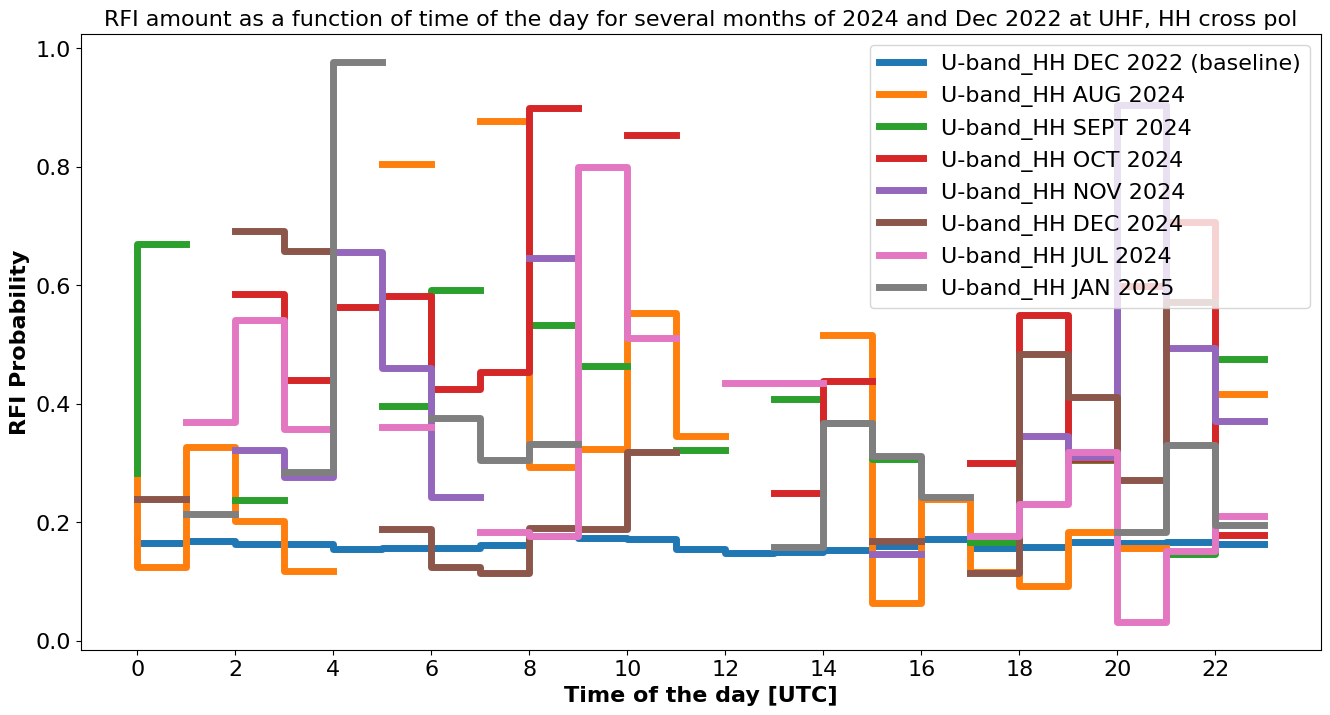

In [25]:
def PlotWithStat(time_array,ProbArray,legend, fig=None):
    '''
    This function will produce plot for Prob as function of time of the day 
    We can do frequemcy selction using StartFreq,EndFreq
    StartFreq,EndFreq - start and End frequency in GHz - obsolete can remove
    ProbArray - 2-D probability array 
    freq - is the full Frequency array 
    name - is the string to put in the title (disabled for now)
    '''

    if fig is None :
        fig = plt.figure(figsize=(16,8))
    
        ax = fig.add_subplot(111)

        #plt.fill_between(np.arange(p.shape[0]), er68[0], er68[1],color='g',alpha=0.3,label=str(con68)+'% Confidence interval')

        ax.set_xlabel('Time [UTC]')
        ax.set_ylabel('Probability')
        ax.set_xticks(np.arange(0,24,2))

    plt.step(np.arange(ProbArray.shape[0]),ProbArray,linewidth=5,label=legend)
    return(fig)

plt.clf()

# Plot the first d)ataset
fig = PlotWithStat(np.arange(24), np.nanmean(dataset_T, axis=0), f'{band}-band_HH DEC 2022 (baseline)')
fig = PlotWithStat(np.arange(24), np.nanmean(dataset1_T, axis=0), f'{band}-band_HH AUG 2024', fig=fig)

# Plot the second dataset on the same axis
fig = PlotWithStat(np.arange(24), np.nanmean(dataset2_T, axis=0), f'{band}-band_HH SEPT 2024', fig=fig)

# Plot the reference dataset on the same axis
fig = PlotWithStat(np.arange(24), np.nanmean(dataset3_T, axis=0), f'{band}-band_HH OCT 2024', fig=fig)
fig = PlotWithStat(np.arange(24), np.nanmean(dataset4_T, axis=0), f'{band}-band_HH NOV 2024', fig=fig)
fig = PlotWithStat(np.arange(24), np.nanmean(dataset5_T, axis=0), f'{band}-band_HH DEC 2024', fig=fig)
fig = PlotWithStat(np.arange(24), np.nanmean(dataset6_T, axis=0), f'{band}-band_HH JUL 2024', fig=fig)
fig = PlotWithStat(np.arange(24), np.nanmean(dataset7_T, axis=0), f'{band}-band_HH JAN 2025', fig=fig)

plt.legend()
plt.xlabel('Time of the day [UTC]')
plt.ylabel('RFI Probability')
plt.title(f'RFI amount as a function of time of the day for several months of 2024 and Dec 2022 at UHF, HH cross pol')
#plt.savefig('Prob_time_rfi_UL-only-April-May_June_HH_2024.png')
plt.show()

In [26]:
pd.DataFrame(dataset1_T)

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.082796,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.157635,NaN,NaN,NaN,NaN,NaN
3,0.338857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.884799,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,0.257390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.092502,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.165572,NaN,NaN,NaN
9,0.346977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


/scratch/kvanqa/miniconda3/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,


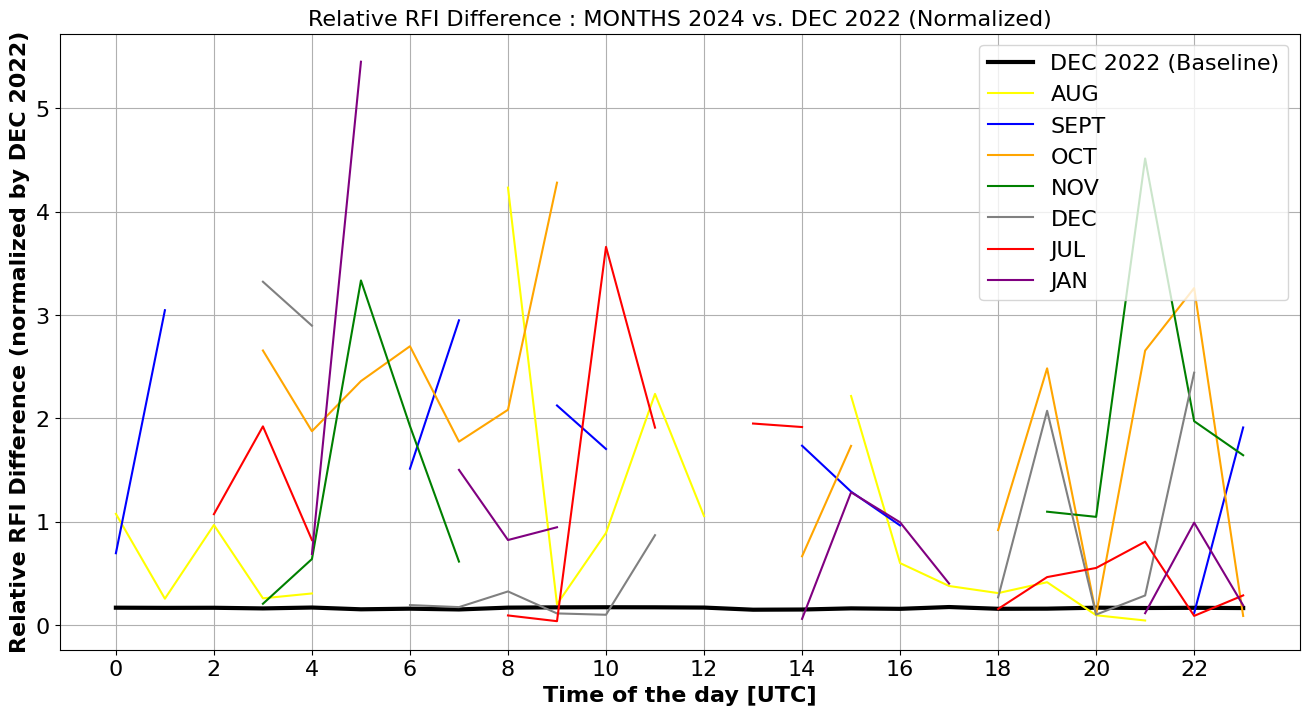

In [27]:
# Calculate the mean RFI amount for each time interval and month
mean_rfi_feb_time = np.nanmedian(dataset_T,axis=0)
mean_rfi_feb2_time = np.nanmedian(dataset6_T,axis=0)
mean_rfi_mar_time = np.nanmedian(dataset1_T,axis=0)
mean_rfi_april_time = np.nanmedian(dataset2_T,axis=0 )
mean_rfi_may_time = np.nanmedian(dataset3_T ,axis=0)
mean_rfi_june_time = np.nanmedian(dataset4_T,axis=0)
mean_rfi_july_time = np.nanmedian(dataset5_T, axis=0)
mean_rfi_JAN_time = np.nanmedian(dataset7_T, axis=0)
# Sample data of average RFI levels for each month
months = [f'Feb_{band}', f'Mar_{band}', f'April_{band}', f'May_{band}', f'June_{band}', f'July_{band}', f'August_{band}', f'Jan_{band}']

# Calculate the relative differences
relative_feb = np.abs(mean_rfi_feb_time - mean_rfi_feb_time) / mean_rfi_feb_time
relative_feb2 = np.abs(mean_rfi_feb2_time - mean_rfi_feb_time) / mean_rfi_feb_time
relative_mar = np.abs(mean_rfi_mar_time - mean_rfi_feb_time) / mean_rfi_feb_time
relative_april = np.abs(mean_rfi_april_time - mean_rfi_feb_time) / mean_rfi_feb_time
relative_June = np.abs(mean_rfi_may_time - mean_rfi_feb_time) / mean_rfi_feb_time
relative_July = np.abs(mean_rfi_june_time - mean_rfi_feb_time) / mean_rfi_feb_time
relative_august = np.abs(mean_rfi_july_time - mean_rfi_feb_time) / mean_rfi_feb_time
relative_jan = np.abs(mean_rfi_JAN_time - mean_rfi_feb_time) / mean_rfi_feb_time

#elative_july = (mean_rfi_july_time - mean_rfi_june_time) / mean_rfi_june_time

# Time data (same for all months)
time_of_day = np.arange(24)  # Assuming you're working with hourly RFI

# Plot
plt.figure(figsize=(16, 8))
plt.plot(time_of_day, mean_rfi_feb_time, label='DEC 2022 (Baseline)', color='black', linewidth=3)
plt.plot(time_of_day, relative_mar, label='AUG', color='yellow')
plt.plot(time_of_day, relative_april, label='SEPT', color='blue')
plt.plot(time_of_day, relative_June, label='OCT', color='orange')
plt.plot(time_of_day, relative_July, label='NOV', color='green')
plt.plot(time_of_day, relative_august,label='DEC', color='grey')
plt.plot(time_of_day, relative_feb2,label='JUL', color='red')
plt.plot(time_of_day, relative_jan,label='JAN', color='purple')
#plt.plot(time_of_day, relative_august, label='August', color='red')

# Labels and title
plt.xticks(np.arange(0,24,2))
plt.xlabel('Time of the day [UTC]')
plt.ylabel('Relative RFI Difference (normalized by DEC 2022)')
plt.title('Relative RFI Difference : MONTHS 2024 vs. DEC 2022 (Normalized)')
plt.legend()
plt.grid(True)

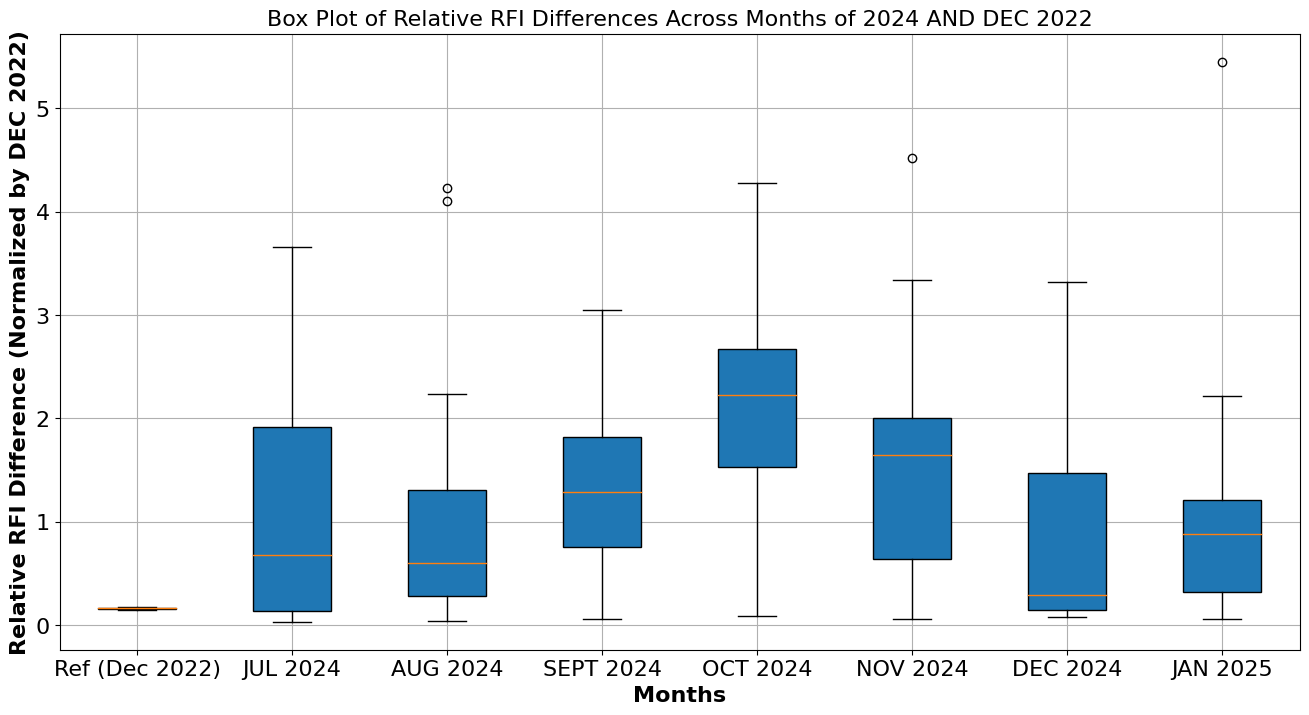

In [28]:
# Check for NaNs or Infs in the data and filter them out
relative_feb_clean = mean_rfi_feb_time #[~np.isnan(mean_rfi_feb_time) & ~np.isinf(mean_rfi_feb_time)]
relative_feb2_clean = relative_feb2[~np.isnan(relative_feb2) & ~np.isinf(relative_feb2)]
relative_mar_clean = relative_mar[~np.isnan(relative_mar) & ~np.isinf(relative_mar)]
relative_april_clean = relative_april[~np.isnan(relative_april) & ~np.isinf(relative_april)]
relative_june_clean = relative_June[~np.isnan(relative_June) & ~np.isinf(relative_June)]
relative_july_clean = relative_July[~np.isnan(relative_July) & ~np.isinf(relative_July)]
relative_august_clean = relative_august[~np.isnan(relative_august) & ~np.isinf(relative_august)]
relative_jan_clean = relative_jan[~np.isnan(relative_jan) & ~np.isinf(relative_jan)]
#_as_baseline_dis = mean_rfi_may_time[~np.isnan(mean_rfi_may_time) & ~np.isinf(mean_rfi_may_time)]

# Combine the relative differences into a list for the box plot
data_for_boxplot = [mean_rfi_feb_time, relative_feb2_clean, relative_mar_clean, relative_april_clean, relative_june_clean, relative_july_clean,relative_august_clean, relative_jan_clean ]

# List of month names for labeling
month_labels = ['Ref (Dec 2022)','JUL 2024', 'AUG 2024', 'SEPT 2024', 'OCT 2024', 'NOV 2024', 'DEC 2024', 'JAN 2025']

# Create the box plot
plt.figure(figsize=(16, 8))
plt.boxplot(data_for_boxplot, patch_artist=True, labels=month_labels)

# Adding labels and title
plt.xlabel('Months')
plt.ylabel('Relative RFI Difference (Normalized by DEC 2022)')
plt.title('Box Plot of Relative RFI Differences Across Months of 2024 AND DEC 2022')
plt.grid(True)

# Show plot
plt.show()

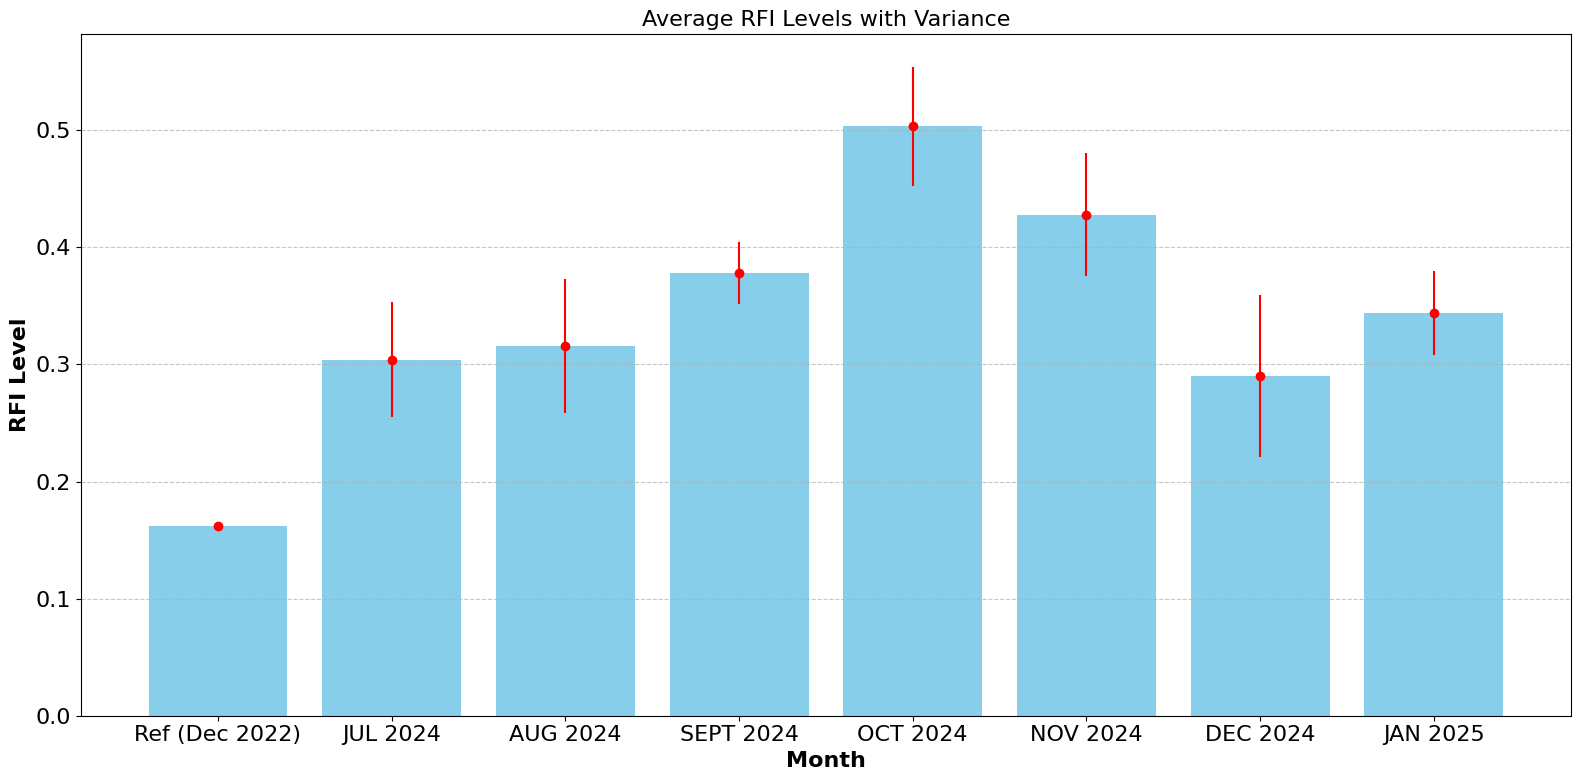

In [29]:
# Sample data of average RFI levels for each month
months = [f'feb_{band}', f'Mar_{band}', f'April_{band}', f'May_{band}', f'June_{band}', f'July_{band}', f'August_{band}']

average = [np.nanmean(mean_rfi_feb_time), np.nanmean(mean_rfi_feb2_time), np.nanmean(mean_rfi_mar_time),np.nanmean(mean_rfi_april_time),np.nanmean(mean_rfi_may_time),
                np.nanmean(mean_rfi_june_time), np.nanmean(mean_rfi_july_time), np.nanmean(mean_rfi_JAN_time)]

# Calculate the variance for each month
variance_feb_u = np.nanvar(dataset_T)
variance_feb2_u = np.nanvar(dataset6_T)
variance_mar_u = np.nanvar(dataset1_T)
variance_april_u = np.nanvar(dataset2_T)
variance_may_u = np.nanvar(dataset3_T )
variance_june_u = np.nanvar(dataset4_T)
variance_july_u = np.nanvar(dataset5_T)
variance_jan_u = np.nanvar(dataset7_T)

# Calculate mean variance and scale factor
variance_scale_factor = 1.0  # Adjust as needed
yerr = [np.nanmean(variance_feb_u) * variance_scale_factor,
        np.nanmean(variance_feb2_u) * variance_scale_factor,
        np.nanmean(variance_mar_u) * variance_scale_factor,
        np.nanmean(variance_april_u) * variance_scale_factor, 
        np.nanmean(variance_may_u) * variance_scale_factor, 
         np.nanmean(variance_june_u) * variance_scale_factor, 
        np.nanmean(variance_july_u) * variance_scale_factor,
        np.nanmean(variance_jan_u) * variance_scale_factor]

# Plotting
plt.figure(figsize=(16, 8))
plt.bar(month_labels, average, color='skyblue', label='Average RFI Level')
plt.errorbar(month_labels, average, yerr=yerr, fmt='o', color='red', label='Variance')

# Adding labels and title
plt.xlabel('Month')
plt.ylabel('RFI Level')
plt.title('Average RFI Levels with Variance')
#plt.legend()

# Show plot
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Adding horizontal grid lines
plt.tight_layout()
plt.savefig(f' With_error_barrs_months_{band}_2024-2025_I_band_HH_pol.png')
plt.show()

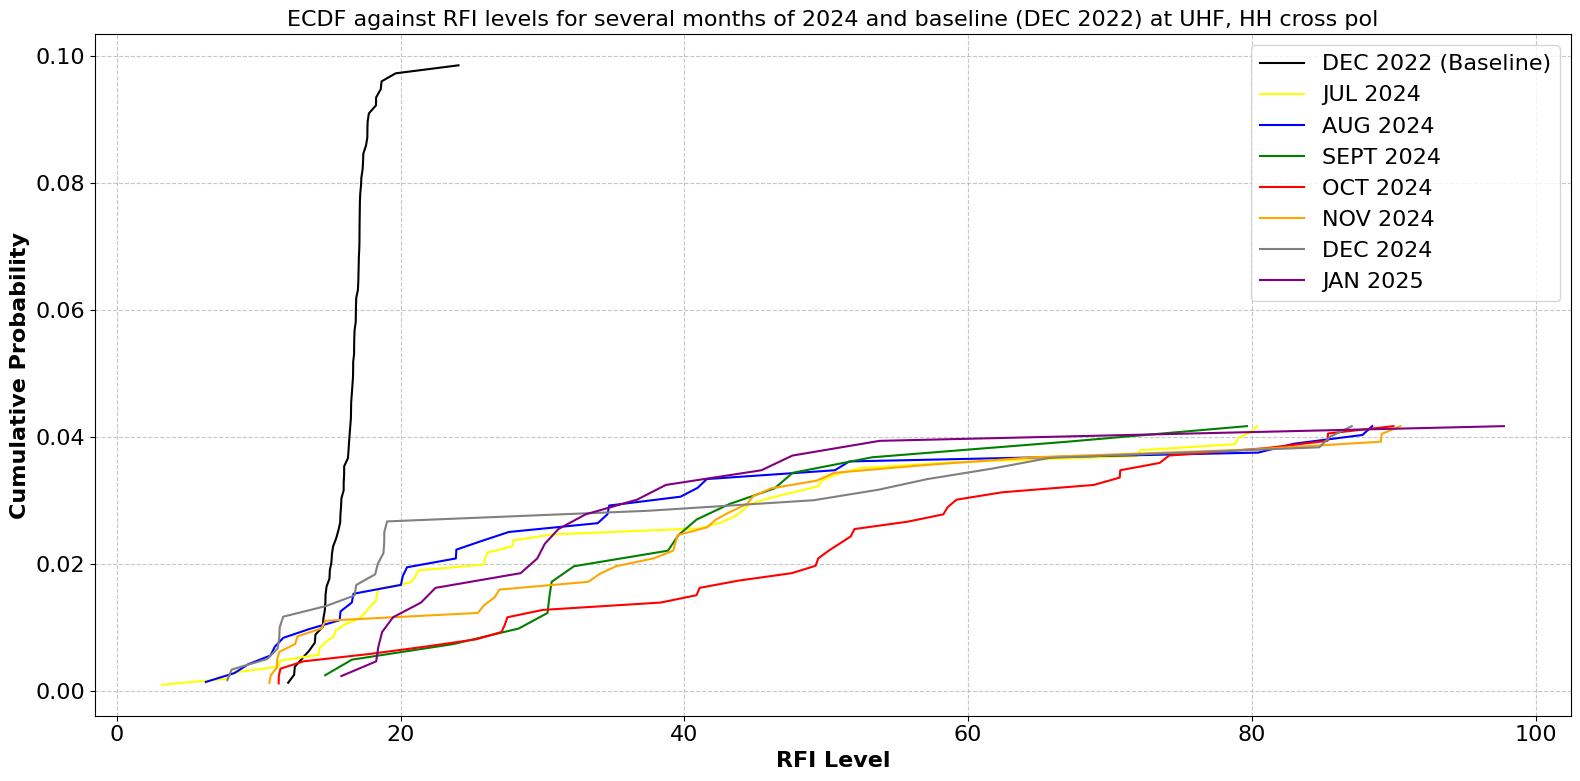

In [30]:
from statsmodels.distributions.empirical_distribution import ECDF


# Calculate the ECDF for each time interval and month
ecdf_feb_time = ECDF(np.asarray(dataset_T).flatten() * 100)
ecdf_feb2_time = ECDF(np.asarray(dataset6_T).flatten() * 100)
ecdf_mar_time = ECDF(np.asarray(dataset1_T).flatten() * 100)
ecdf_april_time = ECDF(np.asarray(dataset2_T).flatten() * 100)
ecdf_may_time = ECDF(np.asarray(dataset3_T).flatten() * 100)
ecdf_june_time = ECDF(np.asarray(dataset4_T).flatten() * 100)
ecdf_july_time = ECDF(np.asarray(dataset5_T).flatten() * 100)
ecdf_jan_time = ECDF(np.asarray(dataset7_T).flatten() * 100)

# Plotting the ECDFs with uncertainty bounds
plt.figure(figsize=(16, 8))

# Plot ECDFs
plt.plot(ecdf_feb_time.x, ecdf_feb_time.y, label='DEC 2022 (Baseline)', color='black')
plt.plot(ecdf_feb2_time.x, ecdf_feb2_time.y, label='JUL 2024', color='yellow')
plt.plot(ecdf_mar_time.x, ecdf_mar_time.y, label='AUG 2024', color='blue')
plt.plot(ecdf_april_time.x, ecdf_april_time.y, label='SEPT 2024', color='green')
plt.plot(ecdf_may_time.x, ecdf_may_time.y, label='OCT 2024', color='red')
plt.plot(ecdf_june_time.x, ecdf_june_time.y, label='NOV 2024', color='orange')
plt.plot(ecdf_july_time.x, ecdf_july_time.y, label='DEC 2024', color='grey')
plt.plot(ecdf_jan_time.x, ecdf_jan_time.y, label='JAN 2025', color='purple')
#plt.plot(ecdf_august_time.x, ecdf_august_time.y, label='August U_band', color='red')

# Adding labels and title
plt.xlabel('RFI Level')
plt.ylabel('Cumulative Probability')
plt.title('ECDF against RFI levels for several months of 2024 and baseline (DEC 2022) at UHF, HH cross pol')
plt.legend()

# Show plot
plt.grid(linestyle='--', alpha=0.7)  # Adding grid lines
plt.tight_layout()
plt.savefig(f' ECDF months_2024-2025_{band}_band_HH_pol.png')
plt.show()

Frequency Analysis

In [31]:
# now we will just read it with pickle as we have dumped it in the sy
DSF = []
for ii in range(len(AllFileNames)+1):
    with open(f'U_hhh_FPX_{ii}.pkl', 'rb') as file:
        datasetsF=  pd.read_pickle(file)
        DSF.append(datasetsF)
# Identify row and column where the probability is zero
dataset_F, dataset1_F, dataset2_F, dataset3_F, dataset4_F, dataset5_F, dataset6_F, dataset7_F = DSF[0], DSF[1], DSF[2],DSF[3], DSF[4], DSF[5], DSF[6], DSF[7]
dataset_F[0][0]

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

In [32]:
frequency2 =  Freq[0][0].to_numpy() // 1e6
frequency2.shape, dataset_F[0][0].shape
# pp = pd.DataFrame(dataset_F[0][0] ,index=frequency2)
# pp

((4096,), (24, 4096))

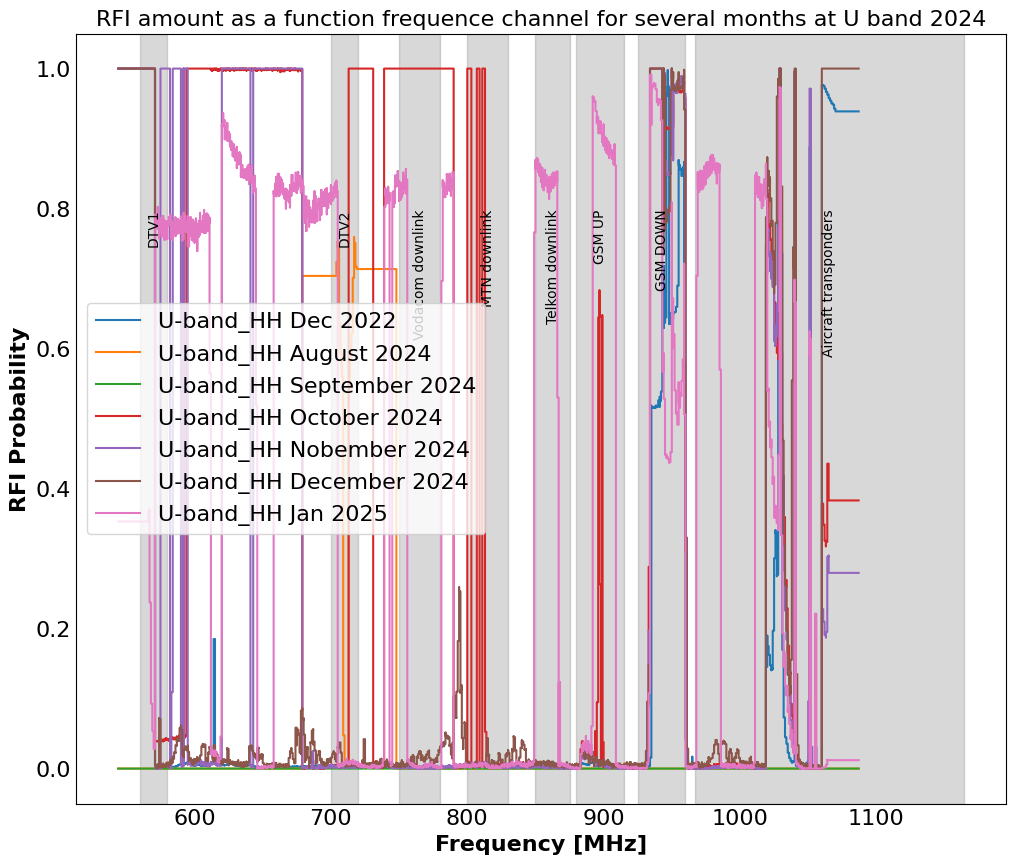

In [33]:
# Shaded frequency bands (example values, adjust to match your figure)
shaded_regions = [
    (560, 580, 'DTV1'),
    (700, 720, 'DTV2'),
    (750, 780, 'Vodacom downlink'),
    (800, 830, 'MTN downlink'),
    (850, 875, 'Telkom downlink'),
    (880, 915, 'GSM UP'),
    (925, 960, 'GSM DOWN'),
    (967, 1164, 'Aircraft transponders')
]

# Add shaded bands and labels
for xmin, xmax, label in shaded_regions:
    plt.axvspan(xmin, xmax, color='gray', alpha=0.3)  # Shaded region
    plt.text((xmin + xmax) / 2, 0.8, label, rotation=90, fontsize=10, ha='center', va='top')

# Hide ticks
plt.tick_params(axis='both', which='both', length=0)


pd.DataFrame(dataset_F[0][0] ,columns=frequency2).median().plot(drawstyle='steps', label=f'{band}-band_HH Dec 2022')
pd.DataFrame(dataset1_F[0][0], columns=frequency2).median().plot(drawstyle='steps', label=f'{band}-band_HH August 2024')
pd.DataFrame(dataset2_F[0][0],columns=frequency2).median().plot(drawstyle='steps', label=f'{band}-band_HH September 2024')
pd.DataFrame(dataset3_F[0][0],columns=frequency2).median().plot(drawstyle='steps', label = f'{band}-band_HH October 2024')
pd.DataFrame(dataset4_F[0][0],columns=frequency2).median().plot(drawstyle='steps', label = f'{band}-band_HH Nobember 2024')
pd.DataFrame(dataset5_F[0][0],columns=frequency2).median().plot(drawstyle='steps', label=f'{band}-band_HH December 2024')
#pd.DataFrame(dataset6_F[0][0],columns=frequency2).median().plot(drawstyle='steps', label=f'{band}-band_HH July 2024')
pd.DataFrame(dataset7_F[0][0],columns=frequency2).median().plot(drawstyle='steps', label=f'{band}-band_HH Jan 2025')

plt.xlabel("Frequency [MHz]")
plt.ylabel("RFI Probability")
plt.title(f'RFI amount as a function frequence channel for several months at {band} band 2024')
plt.legend()
plt.show()

In [120]:
import dash
from dash import dcc, html, Input, Output, dash_table
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sample data (replace with your actual datasets)
band = "UHF"  # Example band
time_range = np.arange(24)
month_labels = ['DEC 2022', 'JUL 2024', 'AUG 2024', 'SEPT 2024', 'OCT 2024', 'NOV 2024', 'DEC 2024', 'JAN 2025']

# Load the summary table
summary_df = pd.read_csv("RFI_summary_statistics.csv")

# Combine datasets into a dictionary for easy access
datasets = {
    'DEC 2022': np.nanmean(dataset_T, axis=0),
    'AUG 2024': np.nanmean(dataset1_T, axis=0),
    'SEPT 2024': np.nanmean(dataset2_T, axis=0),
    'OCT 2024': np.nanmean(dataset3_T, axis=0),
    'NOV 2024': np.nanmean(dataset4_T, axis=0),
    'DEC 2024': np.nanmean(dataset5_T, axis=0),
    'JUL 2024': np.nanmean(dataset6_T, axis=0),
    'JAN 2025': np.nanmean(dataset7_T, axis=0),
}

# Create a DataFrame for boxplot and bar plot
data_for_boxplot = [dataset_T.flatten(), dataset1_T.flatten(), dataset2_T.flatten(),
                    dataset3_T.flatten(), dataset4_T.flatten(), dataset5_T.flatten(),
                    dataset6_T.flatten(), dataset7_T.flatten()]
average = [np.nanmean(d) for d in data_for_boxplot]
yerr = [np.nanstd(d) for d in data_for_boxplot]

# ECDF data (replace with your actual ECDF data)
ecdf_data = {
    'DEC 2022': ECDF(dataset_T.flatten()),
    'JUL 2024': ECDF(dataset1_T.flatten()),
    'AUG 2024': ECDF(dataset2_T.flatten()),
    'SEPT 2024': ECDF(dataset3_T.flatten()),
    'OCT 2024': ECDF(dataset4_T.flatten()),
    'NOV 2024': ECDF(dataset5_T.flatten()),
    'JUL 2024': ECDF(dataset6_T.flatten()),
    'JAN 2025': ECDF(dataset7_T.flatten()),
}

# Combine frequency datasets into a dictionary
frequency_datasets = {
    'DEC 2022': pd.DataFrame(dataset_F[0][0]).median(),
    'AUG 2024': pd.DataFrame(dataset1_F[0][0]).median(),
    'SEPT 2024': pd.DataFrame(dataset2_F[0][0]).median(),
    'OCT 2024': pd.DataFrame(dataset3_F[0][0]).median(),
    'NOV 2024': pd.DataFrame(dataset4_F[0][0]).median(),
    'DEC 2024': pd.DataFrame(dataset5_F[0][0]).median(),
    'JUL 2024': pd.DataFrame(dataset6_F[0][0]).median(),
    'JAN 2025': pd.DataFrame(dataset7_F[0][0]).median(),
}
# Create a 2 dimensional dataset of time and frequency for the heatmap
time_frequency_datasets = {"AUG 2024": np.outer(np.nanmean(dataset1_T, axis=0),pd.DataFrame(dataset1_F[0][0], columns=frequency2).median().to_numpy()) ,
                           "SEPT 2024": np.outer(np.nanmean(dataset2_T, axis=0),pd.DataFrame(dataset2_F[0][0], columns=frequency2).median().to_numpy()),
                           "OCT 2024": np.outer(np.nanmean(dataset3_T, axis=0),pd.DataFrame(dataset3_F[0][0], columns=frequency2).median().to_numpy()),
                           "NOV 2024": np.outer(np.nanmean(dataset4_T, axis=0),pd.DataFrame(dataset4_F[0][0], columns=frequency2).median().to_numpy()),
                           "DEC 2024": np.outer(np.nanmean(dataset5_T, axis=0),pd.DataFrame(dataset5_F[0][0], columns=frequency2).median().to_numpy()),
                           "JAN 2025" : np.outer(np.nanmean(dataset7_T, axis=0),pd.DataFrame(dataset7_F[0][0], columns=frequency2).median().to_numpy())}


# Initialize Dash app
app = dash.Dash(__name__)

# Layout of the dashboard
app.layout = html.Div([
    html.H1("RFI Monitoring Dashboard"), 
    # Summary Section
    html.Div([
        html.H3("Summary"),
        html.P("""
            This dashboard provides an overview of Radio Frequency Interference (RFI) monitoring 
            using MeerKAT data. The visualizations show the intensity of RFI over time and frequency, 
            as well as the mean RFI levels for better analysis. Looking at the summarized version of the 
            January 2025 RFI occupancy. An unusual trend in RFI over frequency compared to previous months is observed.
             While the fractional RFI as a function of time remains consistent with past observations, 
             we see significantly higher RFI levels across a broad range of frequency intervals. 
             Notably, some of these affected frequencies were previously considered RFI-free for MeerKAT.
            This unexpected increase in RFI as a function of frequency could be attributed to several factors, 
            including new interference sources, changes in telescope hardware, or external environmental factors. 

        """)]),
    dcc.Graph(id='time-plot'),
    dcc.Graph(id='box-plot'),
    dcc.Graph(id='bar-plot'),
    dcc.Graph(id='ecdf-plot'),
    dcc.Graph(id='frequency-plot'),
    dcc.Graph(id='time_frequency-plot'),

    html.H3("Monthly Reports"),
    html.Ul([
        html.Li(html.A("August 2024 Report", href="/assets/RFI_Reports_21024_2025/RFI-Report-August-2024.pdf", target="_blank")),
        html.Li(html.A("September 2024 Report", href="/assets/RFI_Reports_21024_2025/RFI-Report-September-2024.pdf", target="_blank")),
        html.Li(html.A("October 2024 Report", href="/assets/RFI_Reports_21024_2025/RFI-Report-October-2024.pdf", target="_blank")),
        html.Li(html.A("November 2024 Report", href="/assets/RFI_Reports_21024_2025/RFI-Report-November-2024.pdf", target="_blank")),
        html.Li(html.A("December 2024 Report", href="/assets/RFI_Reports_21024_2025/RFI-Report-December-2024.pdf", target="_blank")),
        html.Li(html.A("January 2025 Report", href="/assets/RFI_Reports_21024_2025/RFI-Report-January-2025.pdf", target="_blank")),
        # Add links for all other months
    ]),
    html.H3("Monthly Fractional RFI Flagging Datasets"),
    html.Ul([
        html.Li(html.A("August 2024 Dataset", href="/assets/RFI_Datasets/fractional_RFI_August_2024.csv", target="_blank")),
        html.Li(html.A("September 2024 Dataset", href="/assets/RFI_Datasets/fractional_RFI_September_2024.csv", target="_blank")),
        html.Li(html.A("October 2024 Dataset", href="/assets/RFI_Datasets/fractional_RFI_October_2024.csv", target="_blank")),
        html.Li(html.A("November 2024 Dataset", href="/assets/RFI_Datasets/fractional_RFI_November_2024.csv", target="_blank")),
        html.Li(html.A("December 2024 Dataset", href="/assets/RFI_Datasets/fractional_RFI_December_2024.csv", target="_blank")),
        html.Li(html.A("January 2025 Dataset", href="/assets/RFI_Datasets/fractional_RFI_January_2025.csv", target="_blank")),
    ]),
    html.H3("Key RFI Statistics"),
    dash_table.DataTable(
        data=summary_df.to_dict("records"),
        columns=[{"name": col, "id": col} for col in summary_df.columns],
        style_table={"overflowX": "auto"},
        style_cell={"textAlign": "center", "padding": "10px"},
        style_header={"backgroundColor": "lightgrey", "fontWeight": "bold"}
    )
])

# Callback to update plots based on selected month
@app.callback(
    [Output('time-plot', 'figure'),
     Output('box-plot', 'figure'),
     Output('bar-plot', 'figure'),
     Output('ecdf-plot', 'figure'),
     Output('frequency-plot', 'figure'),
     Output('time_frequency-plot', 'figure')],
    [Input('time-plot', 'clickData')]
)
def update_plots(clickData):
    selected_month = None
    if clickData:
        selected_month = month_labels[clickData['points'][0]['curveNumber']]

    # Time plot
    time_fig = go.Figure()
    for month, data in datasets.items():
        time_fig.add_trace(go.Scatter(
            x=time_range, y=data, mode='lines', name=month,
            line=dict(width=10 if month == selected_month else 3, shape='hv'),
            opacity=1 if month == selected_month else 0.5
        ))
    time_fig.update_layout(
        title=f'RFI as a function of time for {band}-band HH',
        xaxis_title='Time of the day [UTC]',
        yaxis_title='Fractional RFI flagged',
    )

    # Box plot
    box_fig = go.Figure()
    for i, month in enumerate(month_labels):
        box_fig.add_trace(go.Box(
            y=data_for_boxplot[i], name=month,
            marker_color='blue' if month == selected_month else 'gray'
        ))
    box_fig.update_layout(
        title='Box Plot of Relative RFI Differences',
        xaxis_title='Months',
        yaxis_title='Relative RFI Difference',
    )

    # Bar plot
    bar_fig = go.Figure()
    bar_fig.add_trace(go.Bar(
        x=month_labels, y=average, name='Average RFI Level',
        error_y=dict(type='data', array=yerr, visible=True),
        marker_color=['blue' if month == selected_month else 'gray' for month in month_labels]
    ))
    bar_fig.update_layout(
        title='Average RFI Levels with Variance',
        xaxis_title='Month',
        yaxis_title='RFI Level',
    )

    # ECDF plot
    ecdf_fig = go.Figure()
    for month, ecdf_vals in ecdf_data.items():
        ecdf_fig.add_trace(go.Scatter(
            x=ecdf_vals.x, y=ecdf_vals.y, mode='lines', name=month,
            line=dict(width=10 if month == selected_month else 3),
            opacity=1 if month == selected_month else 0.5
        ))
    ecdf_fig.update_layout(
        yaxis_type="log",
        title='ECDF of RFI Levels (severity of received RFI)',
        xaxis_title='RFI Level',
        yaxis_title='Cumulative Probability',
    )

    # Frequency plot
    freq_fig = go.Figure()
    for month, data in frequency_datasets.items():
        freq_fig.add_trace(go.Scatter(
            x=frequency2, y=data, mode='lines', name=month,
            line=dict(width=10 if month == selected_month else 3),
            opacity=1 if month == selected_month else 0.5
        ))

    # Add shaded bands and labels on the same axis as the frequency data
    for xmin, xmax, label in shaded_regions:
    # Shaded region
        freq_fig.add_shape(
        type="rect",
        x0=xmin, x1=xmax, y0=0, y1=1,  # Extend to data range
        fillcolor="gray",
        opacity=0.3,
        layer="below",
        line_width=0
    )

    # Add label in the same x-axis
    freq_fig.add_annotation(
        x=(xmin + xmax) / 2, y=1 * 0.9,  # Positioning label slightly below max Y
        text=label,
        showarrow=False,
        font=dict(size=10),
        textangle=90,
        xanchor='center', yanchor='top'
    )
    freq_fig.update_layout(
        title=f'RFI as a function of frequency for {band}-band HH',
        xaxis_title='Frequency [MHz]',
        yaxis_title='Fractional RFI flagged',
    )

    # Create a time_vs_frequency figure
    time_freq_fig = go.Figure()

    # Add heatmaps for each month (initially hidden except AUG 2024)
    months = list(time_frequency_datasets.keys())
    traces = []

    for month in months:
        heatmap = go.Heatmap(
            x=time_range,
            y=frequency2,
            z=time_frequency_datasets[month].T,
            colorscale="Viridis",
            colorbar=dict(title="Intensity"),
            visible=(month == "AUG 2024"),  # Only show the first month initially
            name=month,
        )
        traces.append(heatmap)

    time_freq_fig.add_traces(traces)

    # Create dropdown menu
    dropdown_buttons = [
        {
            "label": month,
            "method": "update",
            "args": [
                {"visible": [m == month for m in months]},  # Show only the selected month
                {"title.text": f"Time vs Frequency Heatmap for {month}"},  # Update title properly
            ],
        }
        for month in months
    ]

    # Update layout with dropdown
    time_freq_fig.update_layout(
        title=dict(text="Time vs Frequency Heatmap"),  # Set title correctly
        xaxis_title="Time",
        yaxis_title="Frequency",
        updatemenus=[
            {
                "buttons": dropdown_buttons,
                "direction": "down",
                "showactive": True,
                "x": 0.1,
                "y": 1.15,
            }
        ],
    )


    return time_fig, box_fig, bar_fig, ecdf_fig, freq_fig, time_freq_fig

# Run the app
import webbrowser
if __name__ == '__main__':
    webbrowser.open("http://0.0.0.0:8080")
    app.run(host='0.0.0.0', port=8080, debug=True)

# if __name__ == '__main__': 
#     app.run_server(jupyter_mode="external", debug=True)

/tmp/ipykernel_2433917/1142273731.py:20: RuntimeWarning:

Mean of empty slice

/tmp/ipykernel_2433917/1142273731.py:21: RuntimeWarning:

Mean of empty slice

/tmp/ipykernel_2433917/1142273731.py:22: RuntimeWarning:

Mean of empty slice

/tmp/ipykernel_2433917/1142273731.py:23: RuntimeWarning:

Mean of empty slice

/tmp/ipykernel_2433917/1142273731.py:24: RuntimeWarning:

Mean of empty slice

/tmp/ipykernel_2433917/1142273731.py:25: RuntimeWarning:

Mean of empty slice

/tmp/ipykernel_2433917/1142273731.py:26: RuntimeWarning:

Mean of empty slice

/tmp/ipykernel_2433917/1142273731.py:60: RuntimeWarning:

Mean of empty slice

/tmp/ipykernel_2433917/1142273731.py:61: RuntimeWarning:

Mean of empty slice

/tmp/ipykernel_2433917/1142273731.py:62: RuntimeWarning:

Mean of empty slice

/tmp/ipykernel_2433917/1142273731.py:63: RuntimeWarning:

Mean of empty slice

/tmp/ipykernel_2433917/1142273731.py:64: RuntimeWarning:

Mean of empty slice

/tmp/ipykernel_2433917/1142273731.py:65: RuntimeWarn

In [56]:
import pandas as pd
import numpy as np

# Define file paths
file_paths = {
    "August 2024": "assets/RFI_Datasets/fractional_RFI_August_2024.csv",
    "September 2024": "assets/RFI_Datasets/fractional_RFI_September_2024.csv",
    "October 2024": "assets/RFI_Datasets/fractional_RFI_October_2024.csv",
    "November 2024": "assets/RFI_Datasets/fractional_RFI_November_2024.csv",
    "December 2024": "assets/RFI_Datasets/fractional_RFI_December_2024.csv",
    "January 2025": "assets/RFI_Datasets/fractional_RFI_January_2025.csv"
}

# Initialize list to store results
stats_data = []

for month, path in file_paths.items():
    df = pd.read_csv(path, index_col=0)  # Load data, first column is timestamps
    df.index = pd.to_datetime(df.index, unit='s')  # Convert timestamps to readable time
    
    # Extract correct year-month from dataset
    month_num = pd.to_datetime(month.split()[0], format='%B').month  # Convert 'August' → 8
    year = int(month.split()[1])  # Extract year
    df = df[df.index.month == month_num]  # Filter only correct month
    df = df[df.index.year == year]  # Ensure correct year

    if df.empty:
        print(f"Warning: No data found for {month}. Skipping...")
        continue

    df_values = df.values.flatten()  # Flatten to 1D array
    
    # Compute statistics
    mean_rfi = np.nanmean(df_values)
    median_rfi = np.nanmedian(df_values)
    std_dev_rfi = np.nanstd(df_values)
    max_rfi = np.nanmax(df_values)
    min_rfi = np.nanmin(df_values)
    
    # Find peak time of RFI (timestamp of row with max value)
    peak_time_idx = df.max(axis=1).idxmax()  # Find timestamp of highest RFI
    peak_time = peak_time_idx.strftime('%Y-%m-%d %H:%M:%S')  # Format as readable date-time
    
    # Find frequency with most RFI (column with max sum)
    freq_with_most_rfi = df.sum(axis=0).idxmax()  # Column with highest total RFI
    
    # Day vs. Night RFI analysis
    day_df = df.between_time('06:00', '18:00')
    night_df = df.between_time('18:00', '06:00')

    mean_day_rfi = np.nanmean(day_df.values.flatten()) if not day_df.empty else np.nan
    mean_night_rfi = np.nanmean(night_df.values.flatten()) if not night_df.empty else np.nan

    # Find peak day & night RFI times
    peak_day_time = day_df.max(axis=1).idxmax().strftime('%Y-%m-%d %H:%M:%S') if not day_df.empty else "N/A"
    peak_night_time = night_df.max(axis=1).idxmax().strftime('%Y-%m-%d %H:%M:%S') if not night_df.empty else "N/A"
    
    # Store results
    stats_data.append([
        month, mean_rfi, median_rfi, std_dev_rfi, max_rfi, min_rfi, peak_time, freq_with_most_rfi,
        mean_day_rfi, mean_night_rfi, peak_day_time, peak_night_time
    ])

# Create DataFrame for summary
columns = [
    "Month", "Mean RFI %", "Median RFI %", "Std Dev", "Max RFI %", "Min RFI %", 
    "Peak Time of RFI", "Hour with Most RFI (UTC)", 
    "Mean Day RFI %", "Mean Night RFI %", "Peak Day RFI Time", "Peak Night RFI Time"
]
summary_df = pd.DataFrame(stats_data, columns=columns)

# Save summary table
summary_df.to_csv("RFI_summary_statistics.csv", index=False)
print("Summary table saved as RFI_summary_statistics.csv")

# Display table
print(summary_df)


Summary table saved as RFI_summary_statistics.csv
            Month  Mean RFI %  Median RFI %   Std Dev  Max RFI %  Min RFI %  \
0     August 2024    0.321593      0.239084  0.239504   0.884799   0.062667   
1  September 2024    0.390171      0.388388  0.162578   0.796539   0.146819   
2    October 2024    0.481411      0.497774  0.225146   0.899771   0.113997   
3   November 2024    0.384062      0.385032  0.229493   0.904623   0.107426   
4   December 2024    0.325991      0.187857  0.262566   0.870361   0.077831   
5    January 2025    0.337157      0.298944  0.189008   0.977609   0.158200   

      Peak Time of RFI Hour with Most RFI (UTC)  Mean Day RFI %  \
0  2024-08-17 22:19:17                        0        0.275099   
1  2024-09-03 23:16:51                        7        0.365529   
2  2024-10-04 06:46:13                        5        0.429938   
3  2024-11-05 19:02:30                       20        0.350375   
4  2024-12-27 17:47:14                        3        0.3191

In [53]:
import pandas as pd
import numpy as np

# Define file paths
file_paths = {
    "August 2024": "assets/RFI_Datasets/fractional_RFI_August_2024.csv",
    "September 2024": "assets/RFI_Datasets/fractional_RFI_September_2024.csv",
    "October 2024": "assets/RFI_Datasets/fractional_RFI_October_2024.csv",
    "November 2024": "assets/RFI_Datasets/fractional_RFI_November_2024.csv",
    "December 2024": "assets/RFI_Datasets/fractional_RFI_December_2024.csv",
    "January 2025": "assets/RFI_Datasets/fractional_RFI_January_2025.csv"
}

# Initialize list to store results
stats_data = []

for month, path in file_paths.items():
    df = pd.read_csv(path, index_col=0)  # Load data
    df.index = df.index.astype(int)
    
    df_values = df.values.flatten()  # Flatten to 1D array
    
    # Compute statistics
    mean_rfi = np.nanmean(df_values)
    median_rfi = np.nanmedian(df_values)
    std_dev_rfi = np.nanstd(df_values)
    max_rfi = np.nanmax(df_values)
    min_rfi = np.nanmin(df_values)
    
    # Find peak time of RFI
    peak_time_idx = np.argmax(df.max(axis=1))  # Row with highest value
    peak_time = df.index[peak_time_idx]  # Get the corresponding datetime
    
    # Find frequency with most RFI
    freq_with_most_rfi = df.sum(axis=0).idxmax()  # Column with highest total RFI

    #freq_with_most_rfi = df.columns[df.max().idxmax()]  # Column name with highest max value
    
    # Store results
    stats_data.append([
        month, mean_rfi, median_rfi, std_dev_rfi, max_rfi, min_rfi, peak_time, freq_with_most_rfi
    ])

# Create DataFrame for summary
columns = [
    "Month", "Mean RFI %", "Median RFI %", "Std Dev", "Max RFI %", "Min RFI %", 
    "Peak Time of RFI", "Hour of the day with Most RFI (UTC)"
]
summary_df = pd.DataFrame(stats_data, columns=columns)

# Save summary table
#summary_df.to_csv("RFI_summary_statistics.csv", index=False)
print("Summary table saved as RFI_summary_statistics.csv")
print(summary_df)

Summary table saved as RFI_summary_statistics.csv
            Month  Mean RFI %  Median RFI %   Std Dev  Max RFI %  Min RFI %  \
0     August 2024    0.321593      0.239084  0.239504   0.884799   0.062667   
1  September 2024    0.390171      0.388388  0.162578   0.796539   0.146819   
2    October 2024    0.481411      0.497774  0.225146   0.899771   0.113997   
3   November 2024    0.384062      0.385032  0.229493   0.904623   0.107426   
4   December 2024    0.325991      0.187857  0.262566   0.870361   0.077831   
5    January 2025    0.337157      0.298944  0.189008   0.977609   0.158200   

   Peak Time of RFI Hour of the day with Most RFI (UTC)  
0        1723933157                                   0  
1        1725405411                                   7  
2        1728024373                                   5  
3        1730833350                                  20  
4        1735321634                                   3  
5        1736047275                             

In [91]:
time_frequency_datasets = {"August": np.outer(np.nanmean(dataset1_T, axis=0),pd.DataFrame(dataset1_F[0][0], columns=frequency2).median().to_numpy()) ,
                           "September": np.outer(np.nanmean(dataset2_T, axis=0),pd.DataFrame(dataset2_F[0][0], columns=frequency2).median().to_numpy()),
                           "October": np.outer(np.nanmean(dataset3_T, axis=0),pd.DataFrame(dataset3_F[0][0], columns=frequency2).median().to_numpy()),
                           "November": np.outer(np.nanmean(dataset4_T, axis=0),pd.DataFrame(dataset4_F[0][0], columns=frequency2).median().to_numpy()),
                           "December": np.outer(np.nanmean(dataset5_T, axis=0),pd.DataFrame(dataset5_F[0][0], columns=frequency2).median().to_numpy()),
                           "January" : np.outer(np.nanmean(dataset7_T, axis=0),pd.DataFrame(dataset7_F[0][0], columns=frequency2).median().to_numpy())}


/tmp/ipykernel_2433917/348805715.py:1: RuntimeWarning:

Mean of empty slice

/tmp/ipykernel_2433917/348805715.py:2: RuntimeWarning:

Mean of empty slice

/tmp/ipykernel_2433917/348805715.py:3: RuntimeWarning:

Mean of empty slice

/tmp/ipykernel_2433917/348805715.py:4: RuntimeWarning:

Mean of empty slice

/tmp/ipykernel_2433917/348805715.py:5: RuntimeWarning:

Mean of empty slice

/tmp/ipykernel_2433917/348805715.py:6: RuntimeWarning:

Mean of empty slice



array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [nan, nan, nan, ..., nan, nan, nan],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]])

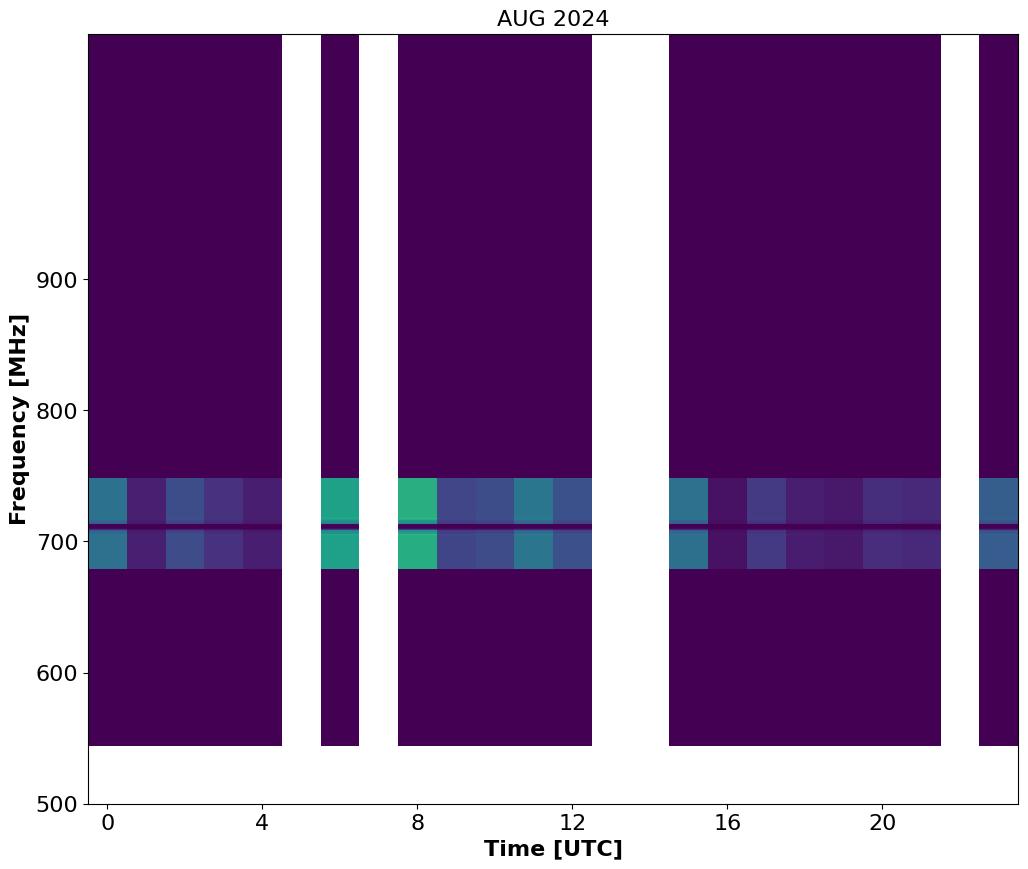

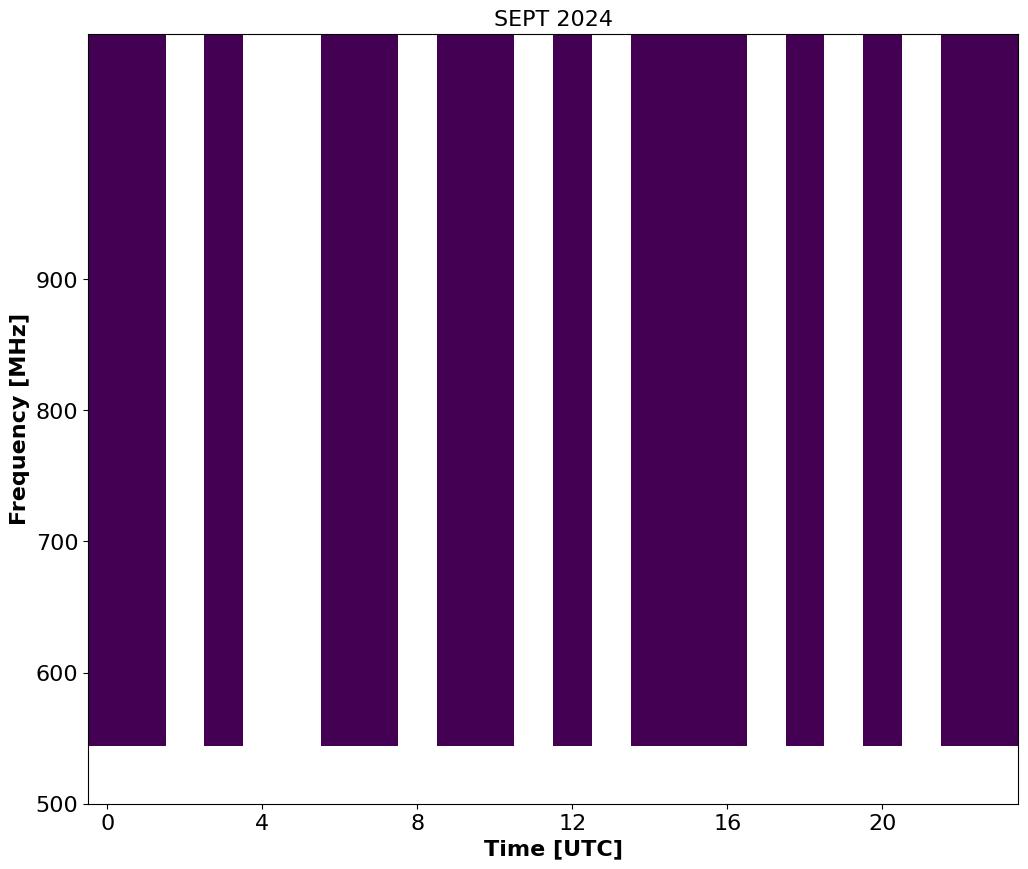

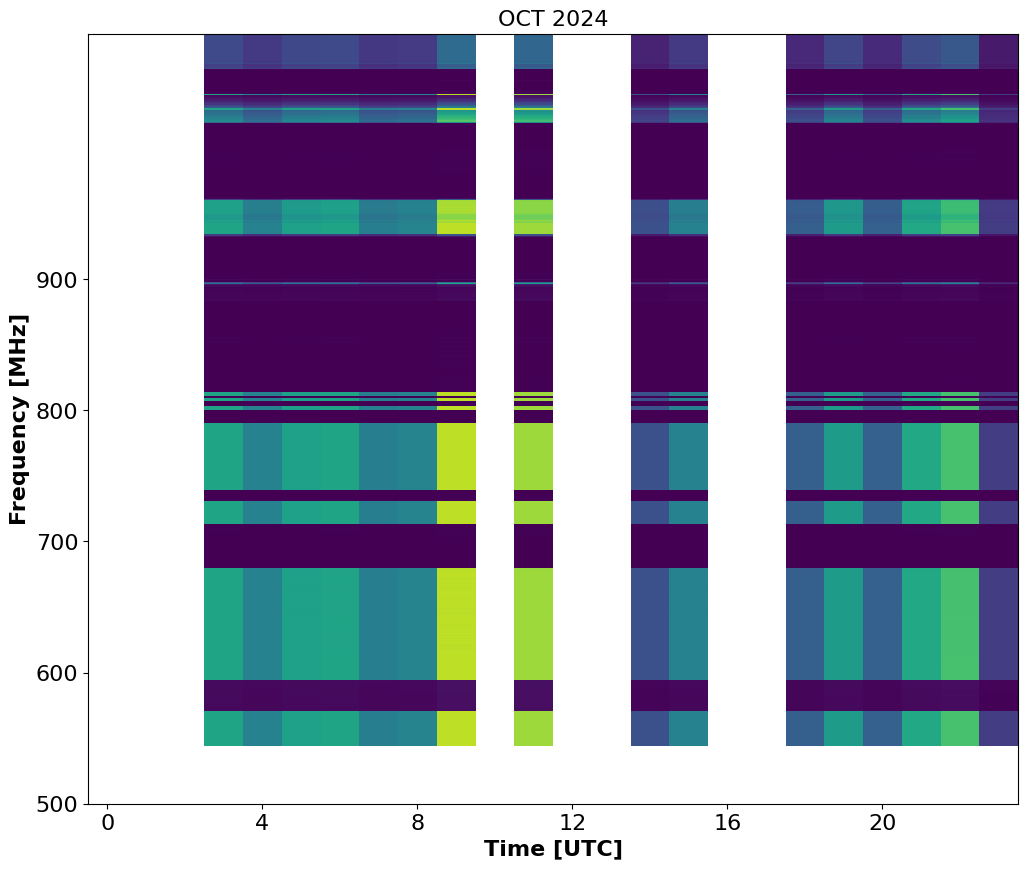

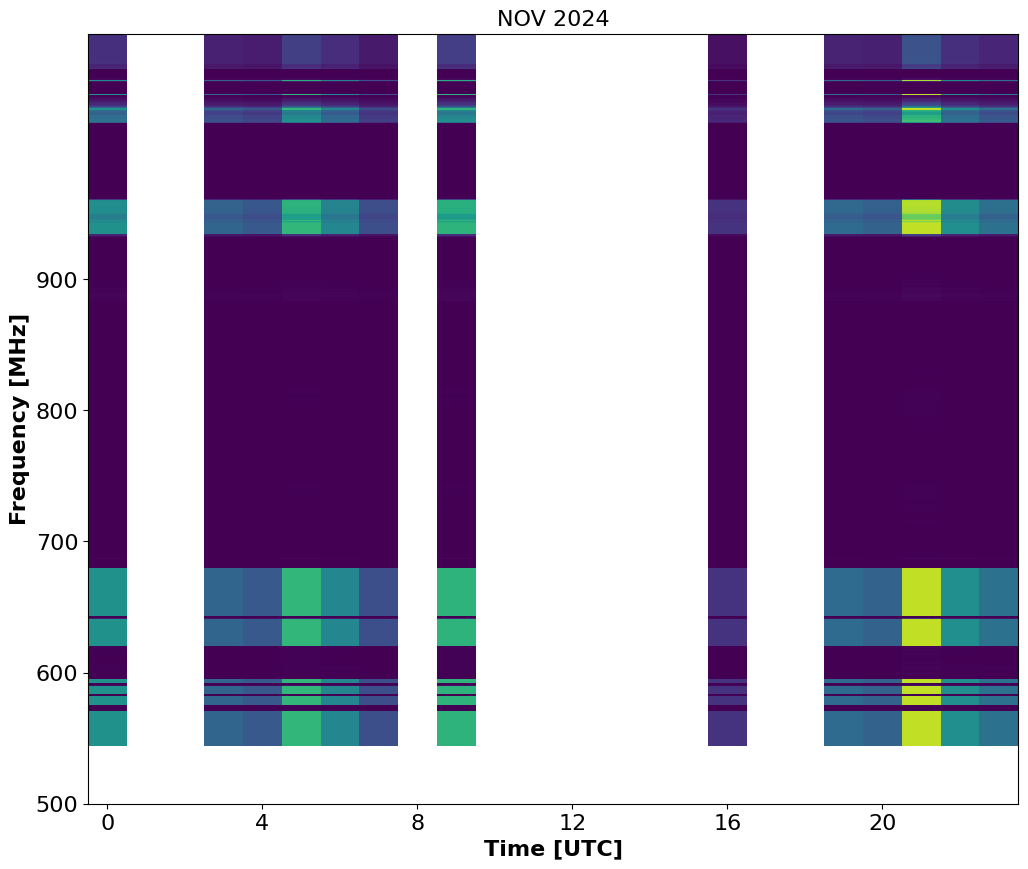

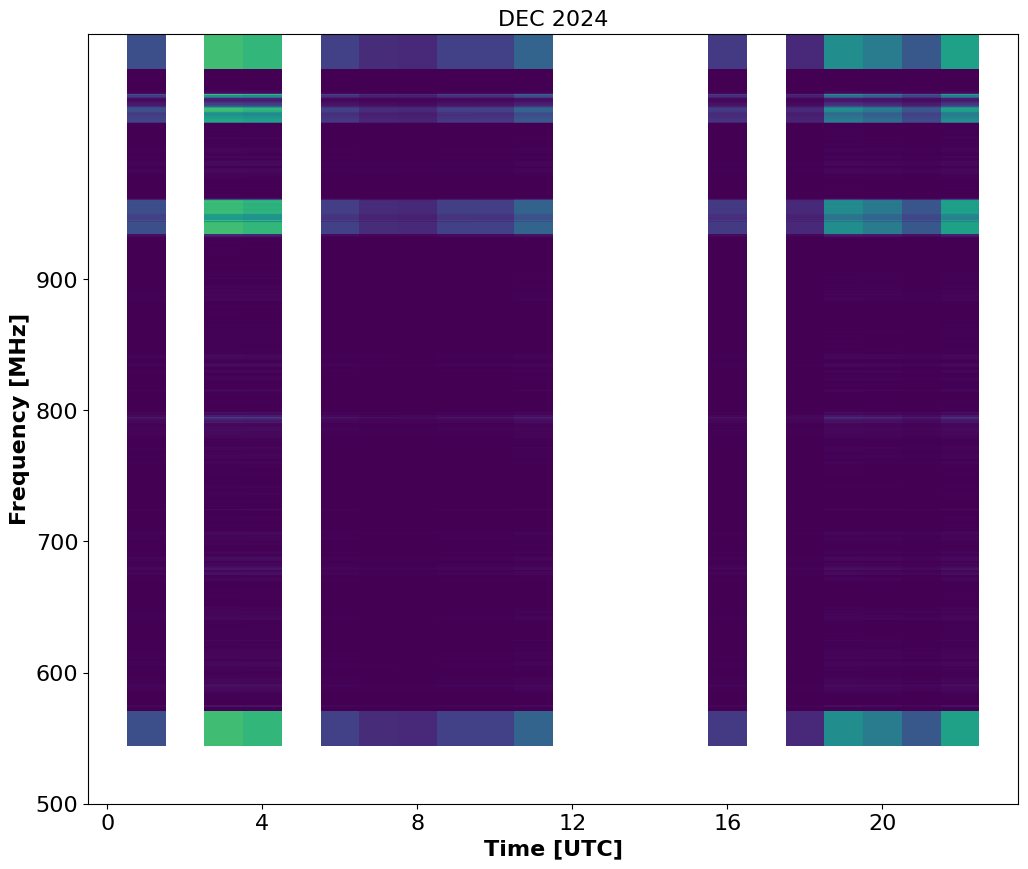

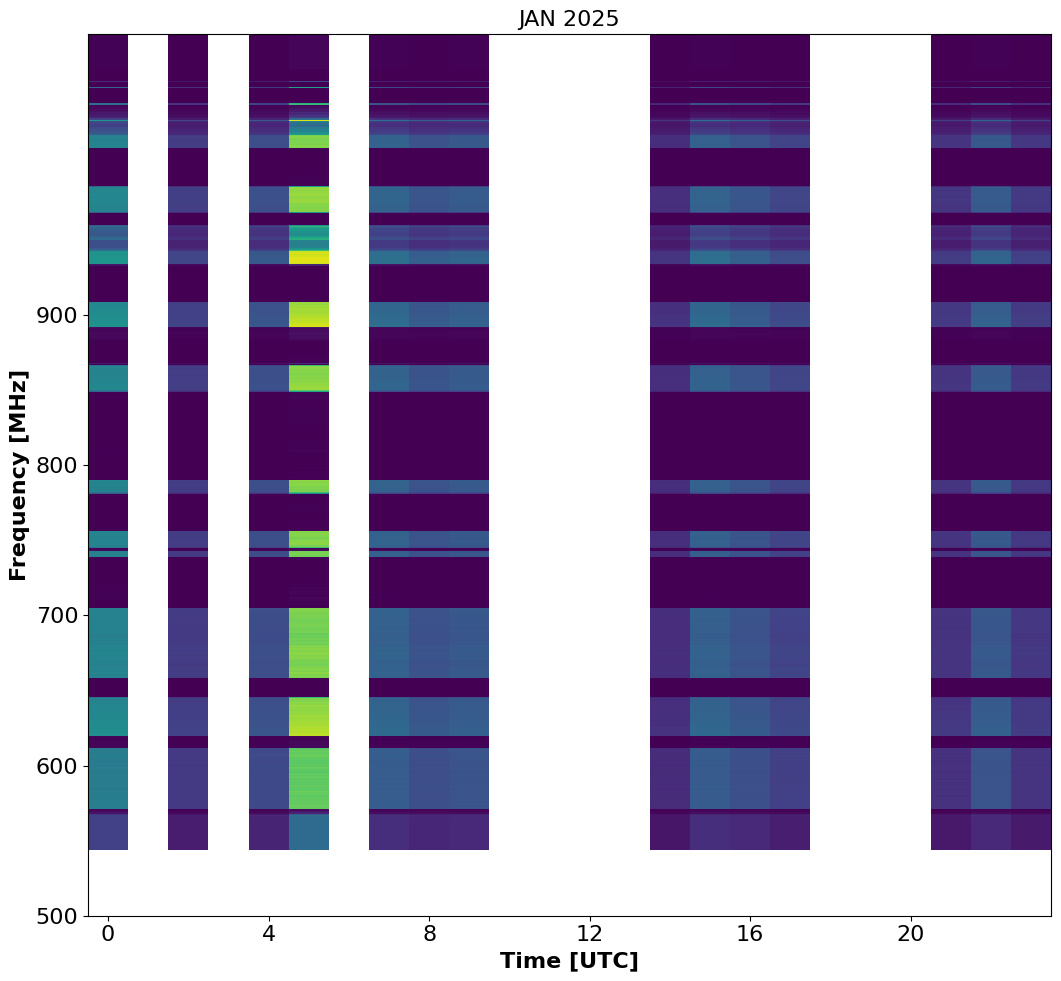

In [114]:
from matplotlib.gridspec import GridSpec

for month, data in time_frequency_datasets.items():
        plt.figure()
        c = plt.pcolormesh(time, frequency2, data.T, shading='auto', cmap='viridis', vmin=0, vmax=1)
        plt.title(month)
        plt.xticks(np.arange(0, 24, 4))
        plt.yticks(np.arange(500, 1000, 100))
        plt.ylabel('Frequency [MHz]')
        plt.xlabel('Time [UTC]')

# Add a colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # Adjust position as needed
fig.colorbar(c, cbar_ax)

plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust layout to accommodate colorbar
plt.show()

In [ ]:
#'/net/stevie/data3/nadeem/KATHPRFI/OUT_ZARR/HH/UBAND/SKA_Baseline',
DATA_PATHS3 = ['/scratch/kvanqa/RFI_work/JAN_HH_U']
#'/home/kvanqa/ALL_WORK/kvanqa/RFI_work/August_U_VH']
           

def GetZarrList(base_dirs, pattern):
    all_files = []
    for base_dir in base_dirs:
        files = glob.glob(os.path.join(base_dir, "**", pattern), recursive=True)
        all_files.append(files)
    return all_files

AllZarrList3 = GetZarrList(DATA_PATHS3,"*.zarr")
    
print(AllZarrList3)
#extraxt the actual files from the path
AllFileNames3 = [[Files.split('_')[-1] for Files in AllZarrList3[i]] for i in range(len(AllZarrList3))]

Freq, Time = [], []
# Define a helper function to open a Zarr file and extract frequency and time
def open_zarr_data(zarr_path, group="arr"):
    dataset = xr.open_zarr(zarr_path, group=group)
# `orr`, `freq`, and `time` will now be tuples containing the datasets, frequencies, and times respectively
    return list(dataset.coords), dataset["frequency"], dataset["time"]

for j in range(len(AllZarrList3)):
    # Use list comprehension to call the helper function
    origDim, freq, time = zip(*(open_zarr_data(zarr_path) for zarr_path in AllZarrList3[j]))
    Freq.append(freq)
    Time.append(time)


[['/scratch/kvanqa/RFI_work/JAN_HH_U/L_HH_1737810974.zarr', '/scratch/kvanqa/RFI_work/JAN_HH_U/L_HH_1736056995.zarr', '/scratch/kvanqa/RFI_work/JAN_HH_U/L_HH_1736035573.zarr', '/scratch/kvanqa/RFI_work/JAN_HH_U/L_HH_1737056773.zarr', '/scratch/kvanqa/RFI_work/JAN_HH_U/L_HH_1737088272.zarr', '/scratch/kvanqa/RFI_work/JAN_HH_U/L_HH_1736047275.zarr', '/scratch/kvanqa/RFI_work/JAN_HH_U/L_HH_1735802773.zarr', '/scratch/kvanqa/RFI_work/JAN_HH_U/L_HH_1737645973.zarr', '/scratch/kvanqa/RFI_work/JAN_HH_U/L_HH_1736015837.zarr', '/scratch/kvanqa/RFI_work/JAN_HH_U/L_HH_1737726495.zarr', '/scratch/kvanqa/RFI_work/JAN_HH_U/L_HH_1736831717.zarr', '/scratch/kvanqa/RFI_work/JAN_HH_U/L_HH_1737786497.zarr', '/scratch/kvanqa/RFI_work/JAN_HH_U/L_HH_1736336007.zarr', '/scratch/kvanqa/RFI_work/JAN_HH_U/L_HH_1737875417.zarr', '/scratch/kvanqa/RFI_work/JAN_HH_U/L_HH_1737424638.zarr', '/scratch/kvanqa/RFI_work/JAN_HH_U/L_HH_1736025731.zarr', '/scratch/kvanqa/RFI_work/JAN_HH_U/L_HH_1738188256.zarr', '/scratch/kv

Baseline RFI Analysis

In [44]:
pickle_file = True


def get_baseline_prob(args):
    all_filenames, index = args
    time_prob = compute(MultiProb(AllZarrList[i], origDims[0][i], ['time']))
    #time_prob = MultiProb(zarr_list, orig_dim, ['time'])
    return time_prob

def process_data(i):
    #orig_dim = open_zarr(AllZarrList[i])
    #orig_dim = GetZarrItem(AllZarrList[i][0])[0]
    BPX_file = f'U_hh_BPX_{i}.pkl'
    if pickle_file and os.path.exists(BPX_file):
        with open(BPX_file, 'rb') as file:
            #return pickle.load(file)
            return pd.read_pickle(file)
    else:
        #pdb.set_trace()
        BPX = get_baseline_prob((AllFileNames[i], i))
        with open(BPX_file, 'wb') as file:
            pickle.dump(TPX, file)
        return BPX

BPX_list = []
for i in range(len(DATA_PATHS)):
    process_data(i)

IndexError: list index out of range

In [48]:
df3

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
1728390685,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.438701,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1730080154,NaN,NaN,NaN,NaN,0.519840,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1729403368,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.517215,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1729473033,NaN,NaN,NaN,0.585639,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1728786975,NaN,NaN,NaN,NaN,NaN,0.509212,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1728734479,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.383236,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1730006355,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.275254,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1730309297,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.410689,NaN,NaN,NaN,NaN
1728194787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.217284,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1729747576,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.735001,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
DATA_PATHS = ['/scratch/kvanqa/RFI_work/2024_UBAND_HH/JUL_HH_U']
#'/home/kvanqa/ALL_WORK/kvanqa/RFI_work/August_U_VH']
           

def GetZarrList(base_dirs, pattern):
    all_files = []
    for base_dir in base_dirs:
        files = glob.glob(os.path.join(base_dir, "**", pattern), recursive=True)
        all_files.append(files)
    return all_files

AllZarrList0 = GetZarrList(DATA_PATHS,"*.zarr")
    
print(AllZarrList0)
#extraxt the actual files from the path
AllFileNames0 = [[Files.split('_')[-1] for Files in AllZarrList0[i]] for i in range(len(AllZarrList0))]

Freq, Time = [], []
origDims = []
baselines = []
elevation_data = []
# Define a helper function to open a Zarr file and extract frequency and time
def open_zarr_data(zarr_path, group="arr"):
    dataset = xr.open_zarr(zarr_path, group=group)
# `orr`, `freq`, and `time` will now be tuples containing the datasets, frequencies, and times respectively
    return list(dataset.coords), dataset["frequency"], dataset["time"], dataset["baseline"], dataset["elevation"]

for j in range(len(AllZarrList0)):
    # Use list comprehension to call the helper function
    origDim, freq, time, baseline, elevation = zip(*(open_zarr_data(zarr_path) for zarr_path in AllZarrList0[j]))
    Freq.append(freq)
    Time.append(time)
    baselines.append(baseline)
    elevation_data.append(elevation)
    origDims.append(origDim)

[['/scratch/kvanqa/RFI_work/2024_UBAND_HH/JUL_HH_U/U_HH_1720844514.zarr', '/scratch/kvanqa/RFI_work/2024_UBAND_HH/JUL_HH_U/U_HH_1721003540.zarr', '/scratch/kvanqa/RFI_work/2024_UBAND_HH/JUL_HH_U/U_HH_1721154027.zarr', '/scratch/kvanqa/RFI_work/2024_UBAND_HH/JUL_HH_U/U_HH_1721074111.zarr', '/scratch/kvanqa/RFI_work/2024_UBAND_HH/JUL_HH_U/U_HH_1720257379.zarr', '/scratch/kvanqa/RFI_work/2024_UBAND_HH/JUL_HH_U/U_HH_1721692871.zarr', '/scratch/kvanqa/RFI_work/2024_UBAND_HH/JUL_HH_U/U_HH_1721145083.zarr', '/scratch/kvanqa/RFI_work/2024_UBAND_HH/JUL_HH_U/U_HH_1720034704.zarr', '/scratch/kvanqa/RFI_work/2024_UBAND_HH/JUL_HH_U/U_HH_1720972111.zarr', '/scratch/kvanqa/RFI_work/2024_UBAND_HH/JUL_HH_U/U_HH_1721492877.zarr', '/scratch/kvanqa/RFI_work/2024_UBAND_HH/JUL_HH_U/U_HH_1720418486.zarr', '/scratch/kvanqa/RFI_work/2024_UBAND_HH/JUL_HH_U/U_HH_1721407405.zarr', '/scratch/kvanqa/RFI_work/2024_UBAND_HH/JUL_HH_U/U_HH_1720745129.zarr', '/scratch/kvanqa/RFI_work/2024_UBAND_HH/JUL_HH_U/U_HH_17197974

In [123]:
!pip install heroku


ERROR: Ignored the following yanked versions: 0.1.0, 0.1.1, 0.1.2, 0.1.3, 0.1.4
ERROR: Could not find a version that satisfies the requirement heroku (from versions: none)
ERROR: No matching distribution found for heroku
